In [60]:
from sklearn.neighbors import NearestNeighbors
import glob
import pandas as pd
from astropy.cosmology import Planck18
from astropy import units as u
import numpy as np
from astropy.coordinates import SkyCoord
from scipy.stats import norm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [61]:
barred_target = pd.read_csv('../data/matched_barred_ps1_resolved.csv')
unbarred_target = pd.read_csv('../data/matched_unbarred_ps1_resolved.csv')

In [62]:
target = pd.read_csv('../all_sample_20260702.csv')
target = pd.merge(target, barred_target[['paliya_RA', 'class']], how='left', on='paliya_RA')
target = pd.merge(target, unbarred_target[['paliya_RA', 'class']], how='left', on='paliya_RA')
target['class'] = target['class_x'].combine_first(target['class_y'])
target = target.drop(['class_x', 'class_y'], axis=1)

target = target[target['class'].isin(['barred', 'unbarred'])]
tg_z = (target.paliya_Z).values
tg_d = Planck18.comoving_distance(target.paliya_Z).value
tg_ra = (target.paliya_RA).values
tg_dec = (target.paliya_DEC).values

coord = SkyCoord(ra = tg_ra * u.deg, dec = tg_dec * u.deg, distance = tg_d * u.Mpc)
tg_df = pd.DataFrame({'coord':coord})

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  84 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 202 out of 202 | elapsed:    5.7s finished


In [68]:
dens

array([['-2.0', '0.0', '1.0', 'barred'],
       ['7.846634285001037', '0.0', '1.4142135623730951', 'barred'],
       ['-2.0', '0.0', '1.0', 'barred'],
       ['-2.0', '0.0', '1.0', 'unbarred'],
       ['-2.0', '0.0', '1.0', 'barred'],
       ['-2.0', '0.0', '1.0', 'barred'],
       ['-2.0', '0.0', '1.0', 'unbarred'],
       ['-2.0', '0.0', '1.0', 'unbarred'],
       ['-2.0', '0.0', '1.0', 'unbarred'],
       ['6.938126442379068', '0.0', '1.4142135623730951', 'unbarred'],
       ['-2.0', '0.0', '1.0', 'unbarred'],
       ['1.0110433460950725', '0.0', '1.7320508075688772', 'unbarred'],
       ['-2.0', '0.0', '1.0', 'barred'],
       ['-2.0', '0.0', '1.0', 'barred'],
       ['0.803685564719405', '0.0', '1.4142135623730951', 'barred'],
       ['-2.0', '0.0', '1.0', 'barred'],
       ['0.9187293975949129', '0.0', '1.4142135623730951', 'unbarred'],
       ['-2.0', '0.0', '1.0', 'barred'],
       ['-2.0', '0.0', '1.0', 'unbarred'],
       ['-2.0', '0.0', '1.0', 'unbarred'],
       ['-2.0', '0

In [ ]:
dens = dens[dens[:,0] != -999.0]

In [ ]:
np.save('./STRM_dens.npy', dens)

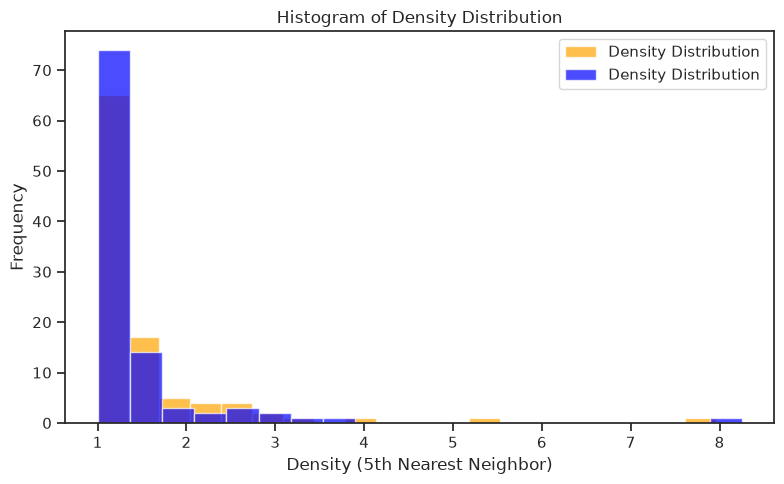

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(dens[:,0][dens[:,-1] == 'barred'].astype(np.float64), bins=20, label='Density Distribution', color='orange', alpha=0.7, cumulative=False)
plt.hist(dens[:,0][dens[:,-1] == 'unbarred'].astype(np.float64), bins=20, label='Density Distribution', color='blue', alpha=0.7, cumulative=False)
plt.xlabel('Density (5th Nearest Neighbor)')
plt.ylabel('Frequency')
plt.title('Histogram of Density Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('../fig/density_distribution_histogram_STRM.png', dpi=300)
plt.show()

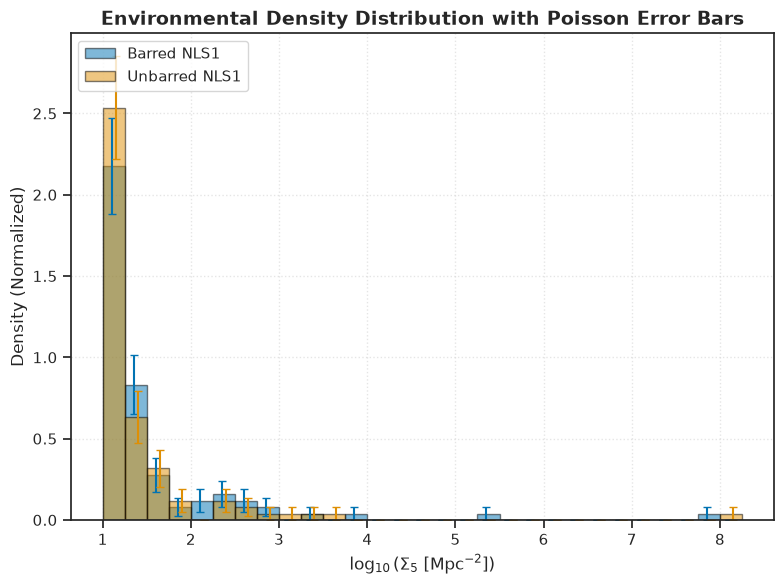

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 直接提取您的數據並轉為 float
b_dens = dens[:, 0][dens[:, -1] == 'barred'].astype(float)
ub_dens = dens[:, 0][dens[:, -1] == 'unbarred'].astype(float)

# 2. 完全交給算法自動決定最優分箱邊界 (bins='auto')，絕不人工限制
all_data = np.concatenate([b_dens, ub_dens])
bins = np.histogram_bin_edges(all_data, bins='auto')
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = np.diff(bins)  # 自動適應每個 bin 的實際寬度

# 3. 創建畫布
plt.figure(figsize=(8, 6))

# 4. 繪製標準的 overlapping plt.hist 並獲取每個 bin 的歸一化高度 (density=True)
b_heights, _, _ = plt.hist(b_dens, bins=bins, alpha=0.5, color='#0173b2', 
                           label='Barred NLS1', edgecolor='black', density=True)

ub_heights, _, _ = plt.hist(ub_dens, bins=bins, alpha=0.5, color='#de8f05', 
                            label='Unbarred NLS1', edgecolor='black', density=True)

# 5. 【拒絕任何 MC】直接解析計算每個 bin 的歸一化泊松誤差（Y 軸誤差棒）
# 獲取每個 bin 的原始星系計數 N
counts_b, _ = np.histogram(b_dens, bins=bins)
counts_ub, _ = np.histogram(ub_dens, bins=bins)

# 歸一化直方圖的泊松誤差公式： \sigma = \sqrt{N} / (N_total * bin_width)
b_bin_errs = np.sqrt(counts_b) / (len(b_dens) * bin_width)
ub_bin_errs = np.sqrt(counts_ub) / (len(ub_dens) * bin_width)

# 6. 在每個自動生成的柱子正上方繪製垂直誤差棒
# 左右微調 10% 的 bin 寬度，防止藍色和橙色的誤差棒完全重疊在一起
plt.errorbar(bin_centers - bin_width * 0.1, b_heights, yerr=b_bin_errs, 
             fmt='none', ecolor='#0173b2', elinewidth=1.5, capsize=3)

plt.errorbar(bin_centers + bin_width * 0.1, ub_heights, yerr=ub_bin_errs, 
             fmt='none', ecolor='#de8f05', elinewidth=1.5, capsize=3)

# 標籤與樣式 (使用 raw string 避免任何 SyntaxWarning)
plt.xlabel(r'$\log_{10}(\Sigma_5 \ [\mathrm{Mpc}^{-2}])$', fontsize=12)
plt.ylabel('Density (Normalized)', fontsize=12)
plt.title('Environmental Density Distribution with Poisson Error Bars', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# dens = []
# for i, idx in enumerate(index_arr):
#     if idx == -999:
#         continue
#     idx = int(idx)
#     file_list = glob.glob(f'../data/catalog/ps1/redshift_STRM/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
#     if len(file_list) == 0:
#         continue
#     df = pd.read_csv(file_list[0])
#     if idx >= len(df):
#         continue
#     row = df.distance_arcmin.iloc[idx] / 60
#     row = np.deg2rad(row)
#     fifth_dis = row * tg_d[i]
#     if fifth_dis <= 0 or not np.isfinite(fifth_dis):
#         continue
#     fifth_dens = 5 / np.pi / fifth_dis**2
#     fifth_dens = np.log(fifth_dens)
#     dens.append(fifth_dens)


In [ ]:
# plt.hist(dens, bins = 50, label = 'Density Distribution', color = 'blue', alpha = 0.7)
# plt.xlabel('Density (5th Nearest Neighbor)')
# plt.ylabel('Frequency')
# plt.title('Histogram of Density Distribution')
# plt.legend()
# plt.savefig('../fig/density_distribution_histogram_STRM.png', dpi=300)
# plt.show()